# UNSW-NB15 — Task 2 Proposed Model (GAT)
Group 5 · CSE475 · Track 1 (GNN)

**Architecture decision baked into this notebook — read before running:**
Humaira's graph has **nodes = hosts**, but the ground-truth labels (`attack_cat`/`Label`) are
per-flow. This notebook derives a **binary host-level label** per node: `1` if that host appears
(as src or dst) in ANY attack flow within its own split, else `0`. This is a scope change from
per-flow classification (what the baseline does) to per-host classification — **state this explicitly
in the report** when comparing macro-F1 against Juju's baseline; it is not a strictly apples-to-apples
comparison unless you also aggregate the baseline's predictions to host-level for a side comparison.

If your grader/supervisor expects strict per-flow comparability instead, the fix is to change the
label derivation to keep the more precise multiclass `attack_cat` per host (majority vote) — a
commented alternative function is included below — or discuss reformulating as edge/flow-level
classification with the team before submission.

**Files needed (edit paths in CONFIG below):**
- From Humaira: `nodes_train/test.pkl`, `edges_temporal_train/test.pkl`, `edges_contact_train/test.pkl`, `graph_build_config.pkl`
- From preprocessing: `side_train/test.pkl`, `train_processed/test_processed.pkl`, `fitted_transforms.pkl`

In [1]:
import os, glob, pickle, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


In [2]:
# Install PyTorch Geometric if missing (versions must match the pre-installed torch build)
try:
    import torch_geometric
    print("torch_geometric already installed:", torch_geometric.__version__)
except ImportError:
    import torch
    TORCH_VER = torch.__version__.split('+')[0]
    CUDA_VER = 'cu' + torch.version.cuda.replace('.', '') if torch.cuda.is_available() else 'cpu'
    os.system(f"pip install -q torch_geometric")
    os.system(f"pip install -q pyg_lib torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-{TORCH_VER}+{CUDA_VER}.html")
    import torch_geometric
    print("Installed torch_geometric:", torch_geometric.__version__)

from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 780.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 52.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 55.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 56.0 MB/s eta 0:00:00
Installed torch_geometric: 2.8.0.post1


## CONFIG — edit these to match your actual file paths / column names

In [3]:
CFG = {
    'graph_dir': '/kaggle/input/datasets/shahiismyname/unsw-nb15-gnn-dataset',
    'prep_dir': '/kaggle/input/datasets/shahiismyname/unsw-nb15-preprocessed-dataset',

    'node_id_col': 'host',
    'edge_src_col': 'source_host',
    'edge_dst_col': 'target_host',
    'edge_feature_cols': ['transition_count', 'time_gap', 'proto_changed', 'port_changed', 'byte_diff', 'pkt_diff'],
    'node_feature_cols': ['avg_duration', 'total_bytes', 'num_connections',
                           'num_as_src', 'num_as_dst', 'num_unique_partners'],

    'flow_host_cols': ['srcip', 'dstip'],
    'flow_label_col': 'Label',
    'flow_id_col': 'flow_id',

    'heads': 2,
    'hidden_dim': 8,
    'dropout': 0.3,
    'lr': 0.001,
    'weight_decay': 5e-4,
    'epochs': 200,
    'patience': 20,
    'val_frac': 0.2,
    'optimizer': 'Adam',

    'out_dir': '/kaggle/working/task2_gnn_outputs',
}
os.makedirs(CFG['out_dir'], exist_ok=True)

## 1. Load Humaira's graph outputs + your preprocessing outputs

In [4]:
def load_pkl(folder, name):
    path = os.path.join(folder, f'{name}.pkl')
    with open(path, 'rb') as f:
        return pickle.load(f)

nodes_train = load_pkl(CFG['graph_dir'], 'nodes_train')
nodes_test = load_pkl(CFG['graph_dir'], 'nodes_test')
edges_temporal_train = load_pkl(CFG['graph_dir'], 'edges_temporal_train')
edges_temporal_test = load_pkl(CFG['graph_dir'], 'edges_temporal_test')
edges_contact_train = load_pkl(CFG['graph_dir'], 'edges_contact_train')
edges_contact_test = load_pkl(CFG['graph_dir'], 'edges_contact_test')

side_train = load_pkl(CFG['prep_dir'], 'side_train')
side_test = load_pkl(CFG['prep_dir'], 'side_test')
train_processed = load_pkl(CFG['prep_dir'], 'train_processed')
test_processed = load_pkl(CFG['prep_dir'], 'test_processed')
fitted_transforms = load_pkl(CFG['prep_dir'], 'fitted_transforms')

print("Loaded all files OK")

Loaded all files OK


In [5]:
from sklearn.preprocessing import StandardScaler

node_scaler = StandardScaler()
nodes_train[CFG['node_feature_cols']] = node_scaler.fit_transform(nodes_train[CFG['node_feature_cols']])
nodes_test[CFG['node_feature_cols']] = node_scaler.transform(nodes_test[CFG['node_feature_cols']])

edge_scaler = StandardScaler()
edges_temporal_train[CFG['edge_feature_cols']] = edge_scaler.fit_transform(edges_temporal_train[CFG['edge_feature_cols']])
edges_temporal_test[CFG['edge_feature_cols']] = edge_scaler.transform(edges_temporal_test[CFG['edge_feature_cols']])

print(edges_temporal_train[CFG['edge_feature_cols']].describe())  # sanity check: means ~0, stds ~1

       transition_count      time_gap  proto_changed  port_changed  \
count      2.678000e+03  2.678000e+03   2.678000e+03  2.678000e+03   
mean      -6.367821e-17  1.591955e-17  -6.500484e-17  3.608432e-16   
std        1.000187e+00  1.000187e+00   1.000187e+00  1.000187e+00   
min       -1.791165e+00 -2.175769e-01  -2.744341e+00 -4.873863e+00   
25%       -1.168220e-01 -1.940090e-01  -1.949961e-01  1.355040e-01   
50%        1.217896e-01 -1.607699e-01   4.130009e-02  2.529479e-01   
75%        5.360601e-01 -1.465392e-01   1.957519e-01  3.953199e-01   
max        1.820348e+01  2.050712e+01   4.300825e+00  6.020815e-01   

         byte_diff      pkt_diff  
count  2678.000000  2.678000e+03  
mean      0.000000  8.490429e-17  
std       1.000187  1.000187e+00  
min     -13.387732 -1.385329e+01  
25%      -0.201363 -4.351672e-01  
50%      -0.030586 -4.882897e-02  
75%       0.137099  2.473703e-01  
max      29.729239  1.516616e+01  


### Schema check — run this before anything else
If any column name below doesn't match CFG above, fix CFG and re-run from the top.

In [6]:
for name, obj in [('nodes_train', nodes_train), ('edges_temporal_train', edges_temporal_train),
                   ('edges_contact_train', edges_contact_train), ('side_train', side_train),
                   ('train_processed', train_processed)]:
    print(f"--- {name} ---")
    print("columns:", list(obj.columns))
    print(obj.head(2))
    print()

--- nodes_train ---
columns: ['node_index', 'host', 'num_connections', 'avg_duration', 'total_bytes', 'num_as_src', 'num_as_dst', 'num_unique_partners']
   node_index         host  num_connections  avg_duration  total_bytes  \
0           0  10.40.170.2        -0.903292     -0.090216    -0.506789   
1           1  10.40.182.1        -0.904556      3.871618    -0.480605   

   num_as_src  num_as_dst  num_unique_partners  
0   -0.533964   -0.535945            -1.472153  
1   -0.517246   -0.554225            -0.958733  

--- edges_temporal_train ---
columns: ['via_host', 'source_host', 'target_host', 'transition_count', 'time_gap', 'proto_changed', 'port_changed', 'byte_diff', 'pkt_diff', 'is_self_loop', 'source_host_idx', 'target_host_idx', 'via_host_idx']
      via_host  source_host  target_host  transition_count  time_gap  \
0  10.40.170.2  10.40.170.2  10.40.170.2          2.684580  7.265665   
1  10.40.182.1  10.40.182.3  10.40.182.3         -1.783042  5.556312   

   proto_changed  

## 2. Derive per-host binary labels (train and test kept fully separate — no leakage)

In [7]:
def derive_host_labels(side_df, processed_df, cfg):
    '''
    Binary host label: 1 if the host appears (as src or dst) in ANY flow with Label==1
    within this split, else 0. Built only from this split's own flows.
    '''
    flow_labels = side_df[[cfg['flow_id_col']] + cfg['flow_host_cols']].merge(
        processed_df[[cfg['flow_id_col'], cfg['flow_label_col']]],
        on=cfg['flow_id_col'], how='inner'
    )

    long = pd.concat([
        flow_labels[[cfg['flow_host_cols'][0], cfg['flow_label_col']]].rename(
            columns={cfg['flow_host_cols'][0]: 'host'}),
        flow_labels[[cfg['flow_host_cols'][1], cfg['flow_label_col']]].rename(
            columns={cfg['flow_host_cols'][1]: 'host'}),
    ], ignore_index=True)

    host_label = long.groupby('host')[cfg['flow_label_col']].max().rename('host_label').reset_index()
    return host_label


host_labels_train = derive_host_labels(side_train, train_processed, CFG)
host_labels_test = derive_host_labels(side_test, test_processed, CFG)

print("Train host label balance:")
print(host_labels_train['host_label'].value_counts(normalize=True))
print("\nTest host label balance:")
print(host_labels_test['host_label'].value_counts(normalize=True))

Train host label balance:
host_label
0    0.714286
1    0.285714
Name: proportion, dtype: float64

Test host label balance:
host_label
0    0.702128
1    0.297872
Name: proportion, dtype: float64


## 3. Build PyG Data objects — temporal graph (train + test)

In [8]:
print("nodes_train columns:", nodes_train.columns.tolist())
print("edges_temporal_train columns:", edges_temporal_train.columns.tolist())
print("edges_contact_train columns:", edges_contact_train.columns.tolist())

nodes_train columns: ['node_index', 'host', 'num_connections', 'avg_duration', 'total_bytes', 'num_as_src', 'num_as_dst', 'num_unique_partners']
edges_temporal_train columns: ['via_host', 'source_host', 'target_host', 'transition_count', 'time_gap', 'proto_changed', 'port_changed', 'byte_diff', 'pkt_diff', 'is_self_loop', 'source_host_idx', 'target_host_idx', 'via_host_idx']
edges_contact_train columns: ['source_host', 'target_host', 'num_flows', 'total_bytes', 'avg_duration', 'is_self_loop', 'source_host_idx', 'target_host_idx']


In [9]:
def build_graph(nodes_df, edges_df, host_labels_df, cfg, edge_feature_cols=None, seed=None):
    nodes_df = nodes_df.merge(host_labels_df, left_on=cfg['node_id_col'], right_on='host', how='left')
    nodes_df['host_label'] = nodes_df['host_label'].fillna(0).astype(int)
    nodes_df = nodes_df.sort_values('node_index').reset_index(drop=True)
    assert (nodes_df['node_index'].values == np.arange(len(nodes_df))).all(), "node_index not contiguous 0..N-1"

    x = torch.tensor(nodes_df[cfg['node_feature_cols']].fillna(0).values, dtype=torch.float)
    y = torch.tensor(nodes_df['host_label'].values, dtype=torch.long)

    edge_index = torch.tensor(
        np.vstack([edges_df['source_host_idx'].values, edges_df['target_host_idx'].values]),
        dtype=torch.long)

    if edge_feature_cols is not None and all(c in edges_df.columns for c in edge_feature_cols):
        edge_attr = torch.tensor(edges_df[edge_feature_cols].fillna(0).values, dtype=torch.float)
    else:
        edge_attr = torch.ones((edge_index.shape[1], len(cfg['edge_feature_cols'])), dtype=torch.float)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

    if seed is not None:
        g = torch.Generator().manual_seed(seed)
        n = data.num_nodes
        perm = torch.randperm(n, generator=g)
        n_val = max(1, int(n * cfg['val_frac']))
        val_mask = torch.zeros(n, dtype=torch.bool); val_mask[perm[:n_val]] = True
        train_mask = torch.zeros(n, dtype=torch.bool); train_mask[perm[n_val:]] = True
        data.train_mask = train_mask
        data.val_mask = val_mask

    return data, nodes_df[cfg['node_id_col']].tolist()


train_data_temporal, train_hosts = build_graph(
    nodes_train, edges_temporal_train, host_labels_train, CFG, CFG['edge_feature_cols'], seed=SEED)
test_data_temporal, test_hosts = build_graph(
    nodes_test, edges_temporal_test, host_labels_test, CFG, CFG['edge_feature_cols'])

train_data_contact, _ = build_graph(
    nodes_train, edges_contact_train, host_labels_train, CFG, edge_feature_cols=None, seed=SEED)
test_data_contact, _ = build_graph(
    nodes_test, edges_contact_test, host_labels_test, CFG, edge_feature_cols=None)

print(train_data_temporal)
print(test_data_temporal)
print("train_mask:", train_data_temporal.train_mask.sum().item(),
      " val_mask:", train_data_temporal.val_mask.sum().item())

Data(x=[49, 6], edge_index=[2, 2678], edge_attr=[2678, 6], y=[49], train_mask=[49], val_mask=[49])
Data(x=[47, 6], edge_index=[2, 2634], edge_attr=[2634, 6], y=[47])
train_mask: 40  val_mask: 9


## 4. GAT model

In [10]:
class GAT(nn.Module):
    def __init__(self, in_dim, edge_dim, hidden_dim, out_dim, heads=4, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        self.gat1 = GATv2Conv(in_dim, hidden_dim, heads=heads, dropout=dropout, edge_dim=edge_dim)
        self.gat2 = GATv2Conv(hidden_dim * heads, out_dim, heads=1, concat=False,
                               dropout=dropout, edge_dim=edge_dim)

    def forward(self, x, edge_index, edge_attr):
        x = F.elu(self.gat1(x, edge_index, edge_attr))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat2(x, edge_index, edge_attr)
        return x

### Dummy-data sanity check
Quick structural check that the model runs end-to-end before trusting it on real data.

In [11]:
_dummy_x = torch.randn(20, len(CFG['node_feature_cols']))
_dummy_edge_index = torch.randint(0, 20, (2, 60))
_dummy_edge_attr = torch.randn(60, len(CFG['edge_feature_cols']))
_dummy_model = GAT(in_dim=_dummy_x.shape[1], edge_dim=_dummy_edge_attr.shape[1],
                    hidden_dim=CFG['hidden_dim'], out_dim=2, heads=CFG['heads'], dropout=CFG['dropout'])
_out = _dummy_model(_dummy_x, _dummy_edge_index, _dummy_edge_attr)
assert _out.shape == (20, 2), _out.shape
print("Dummy forward pass OK:", _out.shape)
del _dummy_x, _dummy_edge_index, _dummy_edge_attr, _dummy_model, _out

Dummy forward pass OK: torch.Size([20, 2])


## 5. Train + evaluate — helper functions

In [12]:
from sklearn.metrics import (precision_recall_fscore_support, confusion_matrix,
                              roc_auc_score, classification_report)
import copy

def get_class_weights(y, device):
    classes, counts = torch.unique(y, return_counts=True)
    raw_weights = len(y) / (len(classes) * counts.float())
    weights = torch.sqrt(raw_weights)
    full_weights = torch.ones(int(classes.max()) + 1)
    for c, w in zip(classes, weights):
        full_weights[c] = w
    return full_weights.to(device)


def train_gat(train_data, cfg, num_classes=2, verbose=True):
    model = GAT(in_dim=train_data.x.shape[1], edge_dim=train_data.edge_attr.shape[1],
                hidden_dim=cfg['hidden_dim'], out_dim=num_classes,
                heads=cfg['heads'], dropout=cfg['dropout']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])

    data = train_data.to(device)
    train_mask = data.train_mask
    val_mask = data.val_mask
    class_weights = get_class_weights(data.y[train_mask], device)

    best_val_loss = float('inf')
    best_state = None
    best_epoch = -1
    patience_ctr = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(cfg['epochs']):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.edge_attr)
        loss = F.cross_entropy(out[train_mask], data.y[train_mask], weight=class_weights)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        model.eval()
        with torch.no_grad():
            out_eval = model(data.x, data.edge_index, data.edge_attr)
            val_loss = F.cross_entropy(out_eval[val_mask], data.y[val_mask], weight=class_weights).item()

        history['train_loss'].append(loss.item())
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            patience_ctr = 0
        else:
            patience_ctr += 1

        if verbose and (epoch % 20 == 0 or epoch == cfg['epochs'] - 1):
            print(f"epoch {epoch:3d}  train_loss {loss.item():.4f}  val_loss {val_loss:.4f}")

        if patience_ctr >= cfg['patience']:
            if verbose:
                print(f"Early stop at epoch {epoch}, best epoch {best_epoch} (val_loss {best_val_loss:.4f})")
            break

    model.load_state_dict(best_state)
    return model, 0.5, best_epoch, history


def train_gat_full(train_data, cfg, epochs, num_classes=2, verbose=True):
    """Unused now — kept for reference only. Blind full-train run without early stopping."""
    model = GAT(in_dim=train_data.x.shape[1], edge_dim=train_data.edge_attr.shape[1],
                hidden_dim=cfg['hidden_dim'], out_dim=num_classes,
                heads=cfg['heads'], dropout=cfg['dropout']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    data = train_data.to(device)
    class_weights = get_class_weights(data.y, device)

    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.edge_attr)
        loss = F.cross_entropy(out, data.y, weight=class_weights)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if verbose and (epoch % 20 == 0 or epoch == epochs - 1):
            print(f"epoch {epoch:3d}  loss {loss.item():.4f}")
    return model


def evaluate_gat(model, test_data, threshold=0.5, num_classes=2):
    model.eval()
    data = test_data.to(device)
    with torch.no_grad():
        out = model(data.x, data.edge_index, data.edge_attr)
        probs = F.softmax(out, dim=1).cpu().numpy()
        preds = (probs[:, 1] >= threshold).astype(int) if num_classes == 2 else probs.argmax(axis=1)
    y_true = data.y.cpu().numpy()

    precision_m, recall_m, f1_m, _ = precision_recall_fscore_support(y_true, preds, average='macro', zero_division=0)
    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(y_true, preds, average='weighted', zero_division=0)
    cm = confusion_matrix(y_true, preds)
    try:
        roc_auc = roc_auc_score(y_true, probs[:, 1]) if num_classes == 2 else roc_auc_score(
            y_true, probs, multi_class='ovr', average='macro')
    except ValueError:
        roc_auc = float('nan')

    metrics = {
        'precision_macro': precision_m, 'recall_macro': recall_m, 'f1_macro': f1_m,
        'precision_weighted': precision_w, 'recall_weighted': recall_w, 'f1_weighted': f1_w,
        'roc_auc': roc_auc, 'confusion_matrix': cm,
    }
    print(classification_report(y_true, preds, zero_division=0))
    print("Confusion matrix:\n", cm)
    print("ROC-AUC:", roc_auc)
    return metrics, preds, probs, y_true

In [13]:
print("train nodes:", train_data_temporal.train_mask.sum().item(),
      " val nodes:", train_data_temporal.val_mask.sum().item())

train nodes: 40  val nodes: 9


## 6. Train + evaluate on the temporal graph (main model)

In [14]:
seeds = [1, 2, 3, 4, 5]
cv_results = []

for s in seeds:
    torch.manual_seed(s); np.random.seed(s); random.seed(s)
    td_temp, _ = build_graph(nodes_train, edges_temporal_train, host_labels_train, CFG,
                              CFG['edge_feature_cols'], seed=s)
    td_cont, _ = build_graph(nodes_train, edges_contact_train, host_labels_train, CFG,
                              edge_feature_cols=None, seed=s)

    m_t, th_t, ep_t, hist_t = train_gat(td_temp, CFG, num_classes=2, verbose=False)
    met_t, *_ = evaluate_gat(m_t, test_data_temporal, threshold=th_t, num_classes=2)
    cv_results.append({'seed': s, 'graph': 'temporal', 'best_epoch': ep_t,
                        'f1_macro': met_t['f1_macro'], 'roc_auc': met_t['roc_auc']})

    m_c, th_c, ep_c, hist_c = train_gat(td_cont, CFG, num_classes=2, verbose=False)
    met_c, *_ = evaluate_gat(m_c, test_data_contact, threshold=th_c, num_classes=2)
    cv_results.append({'seed': s, 'graph': 'contact', 'best_epoch': ep_c,
                        'f1_macro': met_c['f1_macro'], 'roc_auc': met_c['roc_auc']})

cv_df = pd.DataFrame(cv_results)
print("=== CV summary (5 seeds, epoch selection) ===")
print(cv_df.groupby('graph')[['f1_macro', 'roc_auc', 'best_epoch']].agg(['mean', 'std']))

# --- final reported model: reuse the seed-42 split with proper early stopping (no blind retrain) ---
model_temporal, thresh_temporal, ep_temporal, history_temporal = train_gat(train_data_temporal, CFG, num_classes=2)
metrics_temporal, preds_temporal, probs_temporal, y_true_temporal = evaluate_gat(
    model_temporal, test_data_temporal, threshold=thresh_temporal, num_classes=2)

model_contact, thresh_contact, ep_contact, history_contact = train_gat(train_data_contact, CFG, num_classes=2)
metrics_contact, preds_contact, probs_contact, y_true_contact = evaluate_gat(
    model_contact, test_data_contact, threshold=thresh_contact, num_classes=2)

comparison = pd.DataFrame([
    {'graph': 'temporal', **{k: v for k, v in metrics_temporal.items() if k != 'confusion_matrix'}},
    {'graph': 'contact', **{k: v for k, v in metrics_contact.items() if k != 'confusion_matrix'}},
])
print("\n=== Final comparison (early-stopped, seed 42) ===")
print(comparison)

              precision    recall  f1-score   support

           0       1.00      0.15      0.26        33
           1       0.33      1.00      0.50        14

    accuracy                           0.40        47
   macro avg       0.67      0.58      0.38        47
weighted avg       0.80      0.40      0.33        47

Confusion matrix:
 [[ 5 28]
 [ 0 14]]
ROC-AUC: 0.47619047619047616
              precision    recall  f1-score   support

           0       0.81      0.88      0.84        33
           1       0.64      0.50      0.56        14

    accuracy                           0.77        47
   macro avg       0.72      0.69      0.70        47
weighted avg       0.76      0.77      0.76        47

Confusion matrix:
 [[29  4]
 [ 7  7]]
ROC-AUC: 0.8809523809523809
              precision    recall  f1-score   support

           0       1.00      0.33      0.50        33
           1       0.39      1.00      0.56        14

    accuracy                           0.53      

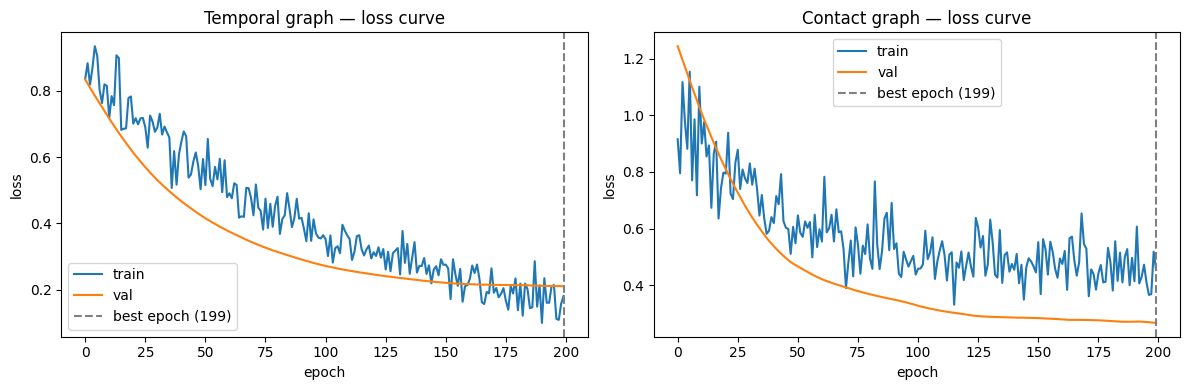

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_temporal['train_loss'], label='train')
axes[0].plot(history_temporal['val_loss'], label='val')
axes[0].axvline(ep_temporal, color='gray', linestyle='--', label=f'best epoch ({ep_temporal})')
axes[0].set_title('Temporal graph — loss curve')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend()

axes[1].plot(history_contact['train_loss'], label='train')
axes[1].plot(history_contact['val_loss'], label='val')
axes[1].axvline(ep_contact, color='gray', linestyle='--', label=f'best epoch ({ep_contact})')
axes[1].set_title('Contact graph — loss curve')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('loss'); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(CFG['out_dir'], 'loss_curves.png'), dpi=150)
plt.show()

## 8. Save model + per-node predictions

In [16]:
torch.save(model_temporal.state_dict(), os.path.join(CFG['out_dir'], 'gat_temporal_model.pt'))

pred_df = pd.DataFrame({
    'host': test_hosts,
    'y_true': y_true_temporal,
    'y_pred': preds_temporal,
    'prob_class_0': probs_temporal[:, 0],
    'prob_class_1': probs_temporal[:, 1],
})
pred_df.to_csv(os.path.join(CFG['out_dir'], 'gat_temporal_test_predictions.csv'), index=False)
pred_df.to_pickle(os.path.join(CFG['out_dir'], 'gat_temporal_test_predictions.pkl'))

with open(os.path.join(CFG['out_dir'], 'gat_metrics_comparison.pkl'), 'wb') as f:
    pickle.dump({'temporal': metrics_temporal, 'contact': metrics_contact,
                 'multi_seed': cv_df, 'thresholds': {'temporal': thresh_temporal, 'contact': thresh_contact}}, f)

print("Saved model + predictions + metrics to", CFG['out_dir'])

Saved model + predictions + metrics to /kaggle/working/task2_gnn_outputs


## 9. Why this architecture — in your own words


Guiding questions to answer here:
- Why GAT specifically (attention over hosts) rather than GCN/GraphSAGE — what does attention
  buy you for this kind of host-communication structure?
- Why 2 GAT layers, not more/fewer — what does layer depth mean for how far information travels
  across the host graph?
- What do the edge features (time gap, protocol/port change, byte/packet diff) let the model learn
  that plain connectivity (the contact graph) can't?
- Why do you expect this to beat Juju's flow-level baseline, given the host-vs-flow scope difference
  noted above — and where might it plausibly lose to the baseline instead?